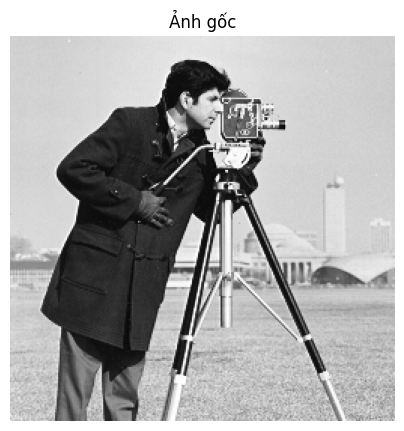

Kích thước ảnh: (256, 256)
Kiểu dữ liệu: uint8
Giá trị mức xám nhỏ nhất: 22
Giá trị mức xám lớn nhất: 255


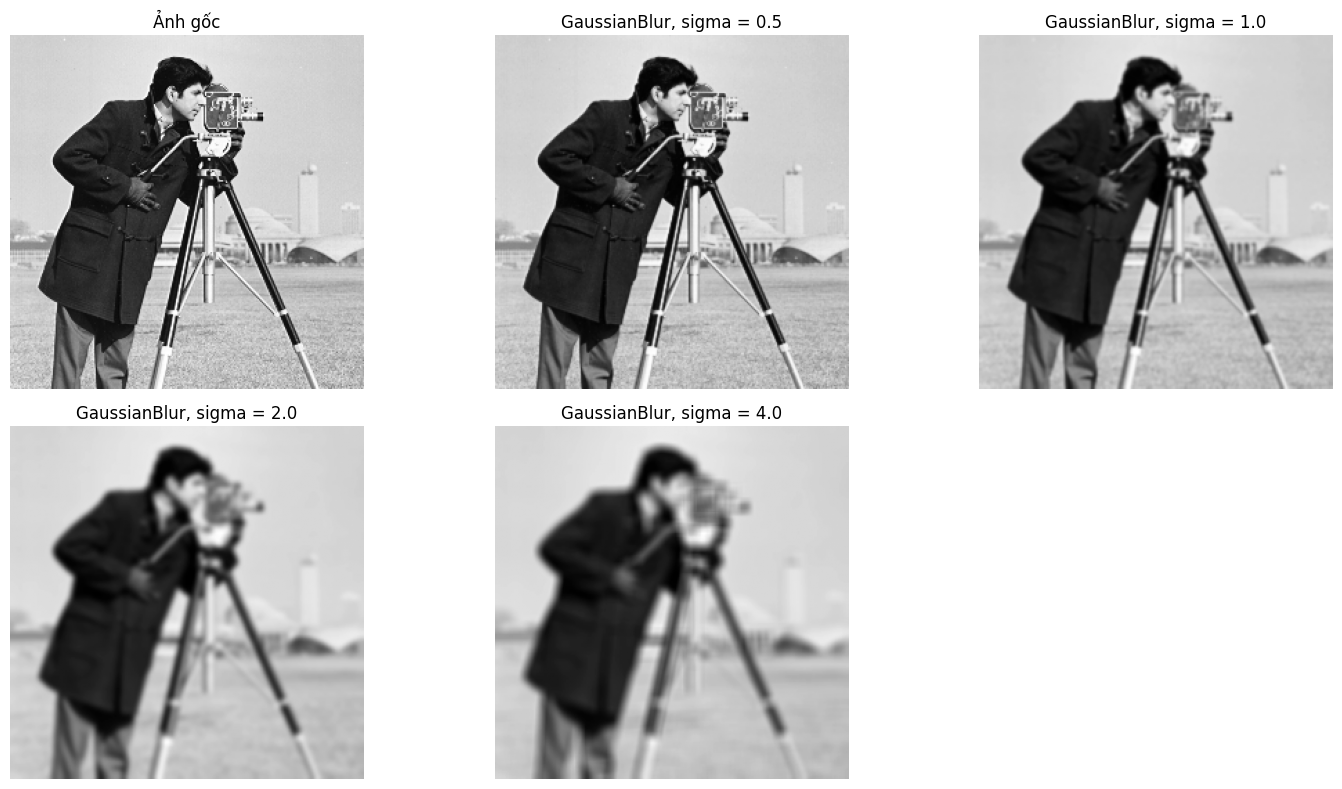

So sánh chỉ số trước và sau khi lọc:
Ảnh gốc:
  - Độ lệch chuẩn mức xám: 68.57833911247839
  - Độ lớn gradient trung bình: 81.07436478281298
Ảnh sau GaussianBlur với sigma = 0.5:
  - Độ lệch chuẩn mức xám: 67.06684066692839
  - Độ lớn gradient trung bình: 70.51514603109278
Ảnh sau GaussianBlur với sigma = 1.0:
  - Độ lệch chuẩn mức xám: 64.7679528856762
  - Độ lớn gradient trung bình: 51.42983768618675
Ảnh sau GaussianBlur với sigma = 2.0:
  - Độ lệch chuẩn mức xám: 62.38863654898727
  - Độ lớn gradient trung bình: 35.21474172320756
Ảnh sau GaussianBlur với sigma = 4.0:
  - Độ lệch chuẩn mức xám: 61.18501681869356
  - Độ lớn gradient trung bình: 30.310692792835447


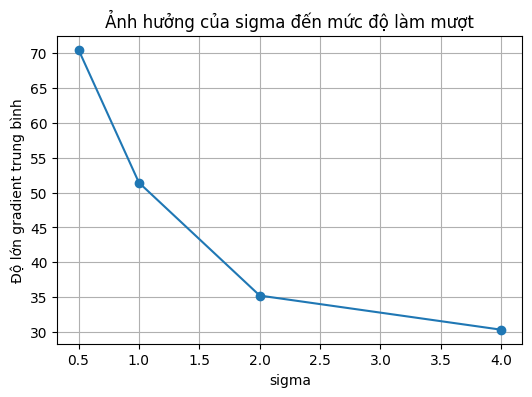

In [1]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: Làm mượt ảnh sử dụng hàm GaussianBlur của OpenCV
# Chương/Mục liên quan: Chương 4 - Mục 4.1.2
# Công thức minh họa: Công thức (4.4) - Bộ lọc Gaussian
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa bài toán làm mượt ảnh bằng bộ lọc Gaussian.
# - Giúp người học quan sát ảnh hưởng của tham số sigma đến mức độ làm mượt.
# - Liên hệ hàm cv2.GaussianBlur với công thức Gaussian trong giáo trình.

# Sau khi chạy code, người học cần:
# 1. Quan sát được ảnh càng bị làm mượt mạnh khi sigma càng lớn.
# 2. Hiểu rằng GaussianBlur thực hiện phép tích chập ảnh với nhân Gaussian.
# 3. Biết thay đổi kích thước cửa sổ lọc và sigma để kiểm tra ảnh hưởng đến kết quả.

# Input:
# - Ảnh đầu vào: cameraman.png
# - Nguồn: https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png
# - Kiểu dữ liệu: ảnh xám

# Output:
# - Ảnh gốc
# - Các ảnh sau khi làm mượt với những giá trị sigma khác nhau
# - Đồ thị so sánh độ biến thiên mức xám trước và sau khi lọc

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

image_url = "https://github.com/lthavnu/cv-book/raw/main/images/cameraman.png"
image_path = "cameraman.png"

urllib.request.urlretrieve(image_url, image_path)

# Đọc ảnh ở chế độ ảnh xám
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Kiểm tra ảnh đã được đọc thành công hay chưa
if img is None:
    raise ValueError("Không đọc được ảnh. Cần kiểm tra lại đường dẫn dữ liệu.")

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")
plt.show()

print("Kích thước ảnh:", img.shape)
print("Kiểu dữ liệu:", img.dtype)
print("Giá trị mức xám nhỏ nhất:", img.min())
print("Giá trị mức xám lớn nhất:", img.max())

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# Trong công thức (4.4), sigma là độ lệch chuẩn của phân bố Gaussian.
# Khi sigma nhỏ, mức làm mượt yếu.
# Khi sigma lớn, mức làm mượt mạnh hơn.

# Kích thước cửa sổ lọc phải là số lẻ, ví dụ: 3, 5, 7, 9, ...
ksize = (9, 9)

# Các giá trị sigma dùng để so sánh
sigma_values = [0.5, 1.0, 2.0, 4.0]

blurred_images = []

for sigma in sigma_values:
    # Dòng lệnh dưới đây tương ứng với việc áp dụng bộ lọc Gaussian theo công thức (4.4)
    # OpenCV tự tạo nhân Gaussian từ ksize và sigma, sau đó tích chập nhân này với ảnh đầu vào.
    blurred = cv2.GaussianBlur(img, ksize, sigmaX=sigma, sigmaY=sigma)
    blurred_images.append(blurred)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Ảnh gốc")
plt.axis("off")

for i, sigma in enumerate(sigma_values):
    plt.subplot(2, 3, i + 2)
    plt.imshow(blurred_images[i], cmap="gray")
    plt.title(f"GaussianBlur, sigma = {sigma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

# Một cách kiểm tra đơn giản:
# Ảnh sau khi làm mượt thường có mức biến thiên cục bộ thấp hơn ảnh gốc.
# Ta đo độ lệch chuẩn của ảnh và độ lớn gradient trung bình để quan sát điều này.

def mean_gradient_magnitude(image):
    # Tính gradient theo hai hướng x và y bằng Sobel
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Tính độ lớn gradient
    grad_mag = np.sqrt(gx**2 + gy**2)

    return grad_mag.mean()

print("So sánh chỉ số trước và sau khi lọc:")
print("Ảnh gốc:")
print("  - Độ lệch chuẩn mức xám:", img.std())
print("  - Độ lớn gradient trung bình:", mean_gradient_magnitude(img))

for sigma, blurred in zip(sigma_values, blurred_images):
    print(f"Ảnh sau GaussianBlur với sigma = {sigma}:")
    print("  - Độ lệch chuẩn mức xám:", blurred.std())
    print("  - Độ lớn gradient trung bình:", mean_gradient_magnitude(blurred))

# Vẽ đồ thị độ lớn gradient trung bình theo sigma
gradient_values = [mean_gradient_magnitude(b) for b in blurred_images]

plt.figure(figsize=(6, 4))
plt.plot(sigma_values, gradient_values, marker="o")
plt.xlabel("sigma")
plt.ylabel("Độ lớn gradient trung bình")
plt.title("Ảnh hưởng của sigma đến mức độ làm mượt")
plt.grid(True)
plt.show()

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# Gợi ý 1:
# Thay đổi sigma_values, ví dụ:
# sigma_values = [0.3, 0.7, 1.5, 3.0, 6.0]
# Quan sát xem ảnh bị mờ dần như thế nào khi sigma tăng.

# Gợi ý 2:
# Thay đổi kích thước cửa sổ lọc:
# ksize = (3, 3), (5, 5), (15, 15)
# Quan sát ảnh hưởng của kích thước cửa sổ đến kết quả làm mượt.

# Gợi ý 3:
# So sánh GaussianBlur với blur trung bình:
# avg_blur = cv2.blur(img, (9, 9))
# Quan sát sự khác nhau giữa làm mượt có trọng số Gaussian và làm mượt trung bình.